# <span style='color:Red'>Misbinding models (Part 0.2)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, jlib, seaborn, pickle
from matplotlib import pyplot
from scipy.stats import vonmises
from joblib import Parallel, delayed

exportsPathTemp = 'exports/biasModels/temp/biasFits/'

if not os.path.exists(exportsPathTemp):
    os.makedirs(exportsPathTemp)

## <span style='color:Red'>Data generator</span>

In [2]:
def generateBias(nTrials,kappa,alpha,guessingP,nNonTargets):
    nonTargets = (numpy.pi+numpy.random.choice(nNonTargets,size=(nTrials,1))*numpy.pi/3)%numpy.pi-numpy.pi
    targets = (numpy.random.uniform(-numpy.pi*20/360,numpy.pi*20/360,size=nTrials)[:,None]+nonTargets).flatten()
    targets = (numpy.pi+targets)%numpy.pi-numpy.pi

    choices = numpy.random.choice(['target','guess'],size=nTrials,p=[1-guessingP,guessingP])
    responses = numpy.zeros(nTrials)
    for i,choice in enumerate(choices):
        if choice == 'target':
            responses[i] = vonmises.rvs(kappa,loc=targets[i]+alpha*(nonTargets[i]-targets[i]))
        else:
            responses[i] = numpy.random.uniform(-numpy.pi,numpy.pi)

    responses = (responses+numpy.pi)%(2*numpy.pi)-numpy.pi
    
    return responses,targets,nonTargets

## <span style='color:Red'>Model fits</span>

In [3]:
nAttempts = 20
dataPoints = 10000

kappa = 10
biasRange = numpy.array(range(0,10))/10
guessingRange = numpy.array(range(0,8))/10

def _runModelSimulation(kappa,bias,guessing):
    allParams = []
    for i in range(nAttempts):
        numpy.random.seed(int(bias*1000+guessing*100+i))

        responseBias,targetBias,nonTargetBias = generateBias(dataPoints,kappa,bias,guessing,6)

        paramsBias_Bias = jlib.analysis.models.fitBiasedModel(targetBias-responseBias,targetBias-nonTargetBias.flatten(),[1,0.5,0.1],
                                                            ((1e-6,numpy.inf),(-1,1),(0,1)))
        LLBias_Bias = jlib.analysis.models._biasedNLL(paramsBias_Bias.x,targetBias-responseBias,targetBias-nonTargetBias.flatten())
        fitBias_Bias = {'kappa':paramsBias_Bias.x[0],'bias':paramsBias_Bias.x[1],'guessingP':paramsBias_Bias.x[2]}
        allParams.append(fitBias_Bias)

    return [bias,guessing],allParams

outputs = Parallel(n_jobs=5,verbose=10)(delayed(_runModelSimulation)(kappa,bias,guessing) 
                                        for bias in biasRange for guessing in guessingRange)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    6.0s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    9.5s
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed:   15.6s
[Parallel(n_jobs=5)]: Done  22 tasks      | elapsed:   21.9s
[Parallel(n_jobs=5)]: Done  31 tasks      | elapsed:   28.4s
[Parallel(n_jobs=5)]: Done  40 tasks      | elapsed:   35.3s
[Parallel(n_jobs=5)]: Done  51 tasks      | elapsed:   45.3s
[Parallel(n_jobs=5)]: Done  62 tasks      | elapsed:   53.6s
[Parallel(n_jobs=5)]: Done  80 out of  80 | elapsed:  1.1min finished


In [4]:
biasMatrix = numpy.zeros((biasRange.shape[0],guessingRange.shape[0]))
guessingMatrix = numpy.zeros((biasRange.shape[0],guessingRange.shape[0]))

for item in outputs:
    biasIndex = numpy.argwhere(biasRange==item[0][0])
    guessingIndex = numpy.argwhere(guessingRange==item[0][1])

    meanBias = 0
    meanGuessing = 0
    for params in item[1]:
        meanBias += params['bias']/nAttempts
        meanGuessing += params['guessingP']/nAttempts
    
    biasMatrix[biasIndex,guessingIndex] = meanBias
    guessingMatrix[biasIndex,guessingIndex] = meanGuessing

In [5]:
import scipy

biasF = biasMatrix.flatten()
biasFT = numpy.transpose(numpy.tile(biasRange,(guessingRange.shape[0],1))).flatten()

a = scipy.stats.pearsonr(biasF,biasFT)

guessingF = guessingMatrix.flatten()
guessingFT = numpy.tile(guessingRange,(1,biasRange.shape[0])).flatten()

b = scipy.stats.pearsonr(guessingF,guessingFT)

c = scipy.stats.pearsonr(biasF,guessingFT)
d = scipy.stats.pearsonr(guessingF,biasFT)

a,b,c,d

(PearsonRResult(statistic=0.9999872729648005, pvalue=6.010779980503257e-181),
 PearsonRResult(statistic=0.9999781903358936, pvalue=7.976370090240172e-172),
 PearsonRResult(statistic=-0.00024444255168130664, pvalue=0.998282993610381),
 PearsonRResult(statistic=-0.0005648864803443582, pvalue=0.9960321535538533))

In [17]:
biasX = []
biasY = []
guessingX = []
guessingY = []
for item in outputs:
    for subitem in item[1]:
        biasY.append(item[0][0])
        guessingY.append(item[0][1])
        biasX.append(subitem['bias'])
        guessingX.append(subitem['guessingP'])

w = scipy.stats.pearsonr(biasX,biasY)
x = scipy.stats.pearsonr(guessingX,guessingY)
y = scipy.stats.pearsonr(biasX,guessingY)
z = scipy.stats.pearsonr(guessingX,biasY)

w,x,y,z

(PearsonRResult(statistic=0.99976011847988, pvalue=0.0),
 PearsonRResult(statistic=0.9995532742534574, pvalue=0.0),
 PearsonRResult(statistic=-0.000244387024752681, pvalue=0.992206514168837),
 PearsonRResult(statistic=-0.0005646464457590619, pvalue=0.9819947036405834))

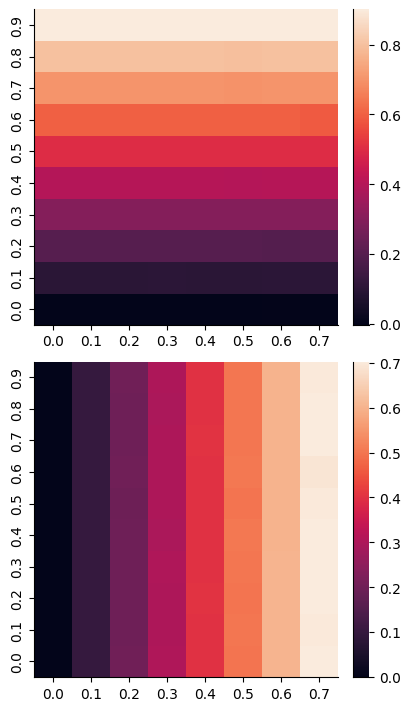

In [6]:
fig,ax = pyplot.subplots(2,1,figsize=(4,7),constrained_layout=True)

seaborn.heatmap(ax=ax[0],data=numpy.flipud(biasMatrix),xticklabels=guessingRange,yticklabels=numpy.flip(biasRange))
seaborn.heatmap(ax=ax[1],data=numpy.flipud(guessingMatrix),xticklabels=guessingRange,yticklabels=numpy.flip(biasRange))

seaborn.despine()

In [7]:
dataToSaveBias = {'data':numpy.flipud(biasMatrix),'x':guessingRange,'y':numpy.flip(biasRange)}
dataToSaveGuessing = {'data':numpy.flipud(guessingMatrix),'x':guessingRange,'y':numpy.flip(biasRange)}

with open(exportsPathTemp+'biasData.pkl','wb') as fp:
    pickle.dump(dataToSaveBias,fp)
with open(exportsPathTemp+'guessingData.pkl','wb') as fp:
    pickle.dump(dataToSaveGuessing,fp)